In [37]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path.cwd().parent  # or use an absolute path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [38]:
import numpy as np

from pytagi import Normalizer as normalizer
import pytagi.metric as metric

from experiments.utils import (
    build_model,
    States,
    LookBackBuffer,
    calculate_updates,
    prepare_input,
    adjust_params,
)

from experiments.data_loader import (
    TimeSeriesDataBuilder,
    BatchLoader,
)

# Plotting defaults
import matplotlib as mpl

# Update matplotlib parameters in a single dictionary
mpl.rcParams.update(
    {
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "text.usetex": False,
        "pgf.rcfonts": False,
        "pgf.preamble": r"\usepackage{amsfonts}\usepackage{amssymb}\usepackage{amsmath}",
        "lines.linewidth": 1,  # Set line width to 1
    }
)

In [39]:
time_covariates = ["week_of_year"]
num_features = 1 + len(time_covariates)
input_seq_len = 52
seed = 100
device = "cpu"
model_input_size = input_seq_len + num_features - 1

x_file = [
    "/Users/davidwardan/Library/CloudStorage/OneDrive-Personal/Projects/cuTAGI_DW/data/hq/train100/split_train_values.csv",
]
date_file = [
    "/Users/davidwardan/Library/CloudStorage/OneDrive-Personal/Projects/cuTAGI_DW/data/hq/train100/split_train_datetimes.csv",
]
ts_idx = 17  # index of the time series to filter


data = TimeSeriesDataBuilder(
    x_file=x_file[0],
    date_time_file=date_file[0],
    input_seq_len=input_seq_len,
    output_seq_len=1,
    stride=1,
    time_covariates=time_covariates,
    scale_method="standard",
    order_mode="by_window",
    ts_to_use=[ts_idx],
)


# Build model
model, output_updater = build_model(
    input_size=model_input_size,
    use_AGVI=True,
    seed=seed,
    device=device,
    init_params="/Users/davidwardan/Library/CloudStorage/OneDrive-Personal/Projects/cuTAGI_DW/out/seed42/train100/BySeries_Obs_global_no-embeddings/param/model.bin",
    shift_biases=False,
)

In [40]:
def filter(net, output_updater, data):

    # Initalize states
    cap = 853
    # cap = 420
    prior_states = States(nb_ts=1, total_time_steps=cap)
    posterior_states = States(nb_ts=1, total_time_steps=cap)

    # Initialize separate uncertainty storage
    prior_states.epistemic = np.full((1, cap), np.nan, dtype=np.float32)
    prior_states.aleatoric = np.full((1, cap), np.nan, dtype=np.float32)
    posterior_states.epistemic = np.full((1, cap), np.nan, dtype=np.float32)
    posterior_states.aleatoric = np.full((1, cap), np.nan, dtype=np.float32)

    batch_iter = BatchLoader.create_data_loader(
        dataset=data.dataset,
        order_mode="by_window",
        batch_size=1,
        shuffle=False,
        seed=1,  # fixed for all seeds and runs
    )

    # Initialize look-back buffer and LSTM state container
    look_back_buffer = LookBackBuffer(input_seq_len=input_seq_len, nb_ts=1)

    net.train()

    y_true = []
    std_y = []
    for (x, y), _, w_id in batch_iter:

        y_true.append(y.flatten())

        # prepare look_back buffer
        if look_back_buffer.needs_initialization[0]:
            look_back_buffer.initialize(
                initial_mu=x[:, :input_seq_len],
                initial_var=np.zeros_like(x[:, :input_seq_len], dtype=np.float32),
                indices=[0],
            )

        # prepare input
        x, var_x = prepare_input(
            x=x,
            var_x=None,
            look_back_mu=(look_back_buffer.mu),
            look_back_var=(look_back_buffer.var),
            indices=np.array([0]),
        )

        # Feedforward
        print(x)
        m_pred, v_pred = net(x, var_x)

        # net.reset_lstm_states()

        # Specific to AGVI
        flat_m = np.ravel(m_pred)
        flat_v = np.ravel(v_pred)

        m_pred = flat_m[::2]  # even indices
        v_pred = flat_v[::2]  # even indices
        var_y = flat_m[1::2]  # odd indices var_v

        s_aleatoric = np.sqrt(var_y)
        std_y.append(s_aleatoric)

        s_epistemic = np.sqrt(v_pred)

        # Store prior states
        prior_states.update(
            new_mu=m_pred,
            new_std=s_epistemic,
            indices=[0],
            time_step=w_id.item(),
        )

        # Update
        m_post, v_post = calculate_updates(
            net,
            output_updater,
            m_pred,
            v_pred,
            y.flatten(),
            use_AGVI=True,
            var_y=var_y,
            train_mode=True,
        )

        s_post_epistemic = np.sqrt(v_post)

        # Store posterior states
        posterior_states.update(
            new_mu=m_post,
            new_std=s_post_epistemic,
            indices=[0],
            time_step=w_id.item(),
        )

        # if y is nan use prior as posterior
        y_lookback = np.where(np.isnan(y.flatten()), m_post, y.flatten())
        v_lookback = np.where(np.isnan(y.flatten()), v_post, 0.0)

        look_back_buffer.update(
            new_mu=y_lookback,
            new_var=v_lookback,
            indices=[0],
        )

    return prior_states, posterior_states, np.array(y_true), np.array(std_y)

In [41]:
import numpy as np
import matplotlib.pyplot as plt

def plot_results_with_baseline(
    prior_states, posterior_states, y_true, std_y, data, plot_baseline=True
):
    # 1. Unstandardize results
    mean = data.x_mean[0][0]
    std = data.x_std[0][0]

    print(mean)
    print(std)

    # Helper for safe unstandardization (avoids modifying original arrays in place if needed)
    prior_mu = normalizer.unstandardize(prior_states.mu, mean, std).flatten()
    prior_std = normalizer.unstandardize_std(prior_states.std, std).flatten()

    # Unstandardize Aleatoric (std_y)
    aleatoric_std = normalizer.unstandardize_std(std_y, std).flatten()

    # Unstandardize Ground Truth
    y_true_unscaled = normalizer.unstandardize(y_true, mean, std).flatten()

    plt.figure(figsize=(10, 3))

    # --- PLOT 1: BASELINE (The "Null Hypothesis") ---
    if plot_baseline:
        # Calculate Baseline: Last observation carried forward
        base_mu = np.roll(y_true_unscaled, 1)
        base_mu[0] = y_true_unscaled[0]

        # Calculate Baseline Uncertainty: Rolling Std Dev of recent truth
        window = 10
        residuals = y_true_unscaled - base_mu
        base_std = np.array([np.std(residuals[max(0, i-window):i+1]) for i in range(len(residuals))])

        # Plot Baseline Mean
        plt.plot(base_mu, color="k", linestyle="--", alpha=0.8, label="Baseline")

        # # Plot Baseline Uncertainty (Gray Band)
        # plt.fill_between(
        #     np.arange(len(base_mu)),
        #     base_mu - 2*base_std, # 2 sigma for 95% confidence
        #     base_mu + 2*base_std,
        #     color="gray",
        #     alpha=0.15,
        #     edgecolor="none",
        #     label="Baseline Uncertainty ($2\sigma$)"
        # )

    # --- PLOT 2: YOUR MODEL (Prior) ---
    x_axis = np.arange(len(prior_mu))

    # 1. Plot Total Uncertainty (Epistemic + Aleatoric)
    # We stack them to show contribution: Outer band = Total
    plt.fill_between(
        x_axis,
        prior_mu - prior_std - aleatoric_std,
        prior_mu + prior_std + aleatoric_std,
        color="blue", # Green for Aleatoric contribution
        alpha=0.3,
        edgecolor="none",
        label=r"Aleatoric Uncertainty"
    )

    # 2. Plot Epistemic Uncertainty (Inner Band)
    plt.fill_between(
        x_axis,
        prior_mu - prior_std,
        prior_mu + prior_std,
        color="blue", # Blue for Epistemic
        alpha=0.4,
        edgecolor="none",
        label=r"Epistemic Uncertainty"
    )

    # 3. Plot Model Mean
    plt.plot(prior_mu, label=r"Model Prediction $\mathbb{E}[y]$", color="b", linewidth=1.5)

    # --- PLOT 3: GROUND TRUTH ---
    plt.plot(y_true_unscaled, label=r"Ground Truth $y_{true}$", color="red", linewidth=1, alpha=0.8)

    # Formatting
    plt.xlabel("Time Index")
    plt.ylabel("Value")

    # Legend placed outside to prevent blocking data
    plt.tight_layout()
    plt.show()

In [42]:
import numpy as np

def get_baseline(y_true, posterior_mu, window_size=10):
    """
    Creates a baseline where:
    - Mu = Previous posterior value (posterior_mu_{t-1})
    - Sigma = Std dev of differences over the last 'window_size' steps

    This tests whether the model is just predicting the same thing as the
    last posterior value from the lookback.
    """
    n = len(y_true)

    # 1. Point Prediction: Use previous posterior value
    # baseline[t] = posterior_mu[t-1]
    baseline_mu = np.roll(posterior_mu, 1)
    baseline_mu[0] = posterior_mu[0]  # Fallback for first element

    # 2. Uncertainty Estimation (Sliding window std of residuals)
    # Calculate residuals (diff between baseline prediction and reality)
    residuals = y_true - baseline_mu

    baseline_std = np.zeros(n)
    for i in range(n):
        start_idx = max(0, i - window_size)
        # Standard deviation of recent errors
        baseline_std[i] = np.std(residuals[start_idx:i+1]) + 1e-6

    return baseline_mu, baseline_std

In [43]:
def compare_results(y_true, model_mu, model_std, base_mu, base_std):
    model_rmse = metric.rmse(model_mu, y_true)
    base_rmse = metric.rmse(base_mu, y_true)

    print(f"--- Comparison ---")
    print(f"RMSE | Model: {model_rmse:.4f} vs Baseline: {base_rmse:.4f}")

In [44]:
# Run model
prior, posterior, y_true, s_aleatoric = filter(model, output_updater, data)

# (Epistemic + Aleatoric)
total_model_std = np.sqrt(prior.std.flatten()**2 + s_aleatoric.flatten()**2)
model_mu = prior.mu.flatten()

# Generate Baseline using previous posterior value
posterior_mu = posterior.mu.flatten()
base_mu, base_std = get_baseline(y_true.flatten(), posterior_mu, window_size=10)

# Compare
compare_results(y_true.flatten(), model_mu, total_model_std, base_mu, base_std)

[-1.4507401  -1.4104557  -1.405742   -1.3476725  -1.2896029  -1.0477518
 -0.82961434 -0.77154475 -0.64233387 -0.5427652  -0.40169752 -0.2309876
 -0.05434928  0.08079002  0.1839157   0.32241446  0.420995    0.5146353
  0.63198924  0.7078442   0.78369904  0.83584017  0.8701961   0.94605106
  1.0159774   1.0621903   1.0906177   1.1071883   1.1296872   1.1284723
  1.1450431   1.1675421   1.1781843   1.1236134   0.9741878   0.91368866
  0.84726125  0.72154933  0.5958374   0.369342    0.16656052 -0.21407418
 -0.55913824 -0.7797051  -0.8757748  -1.1496977  -1.1805545  -1.2054831
 -1.2719107  -1.3798373  -1.4759068  -1.5838335   0.5358865 ]
[-1.4104557  -1.405742   -1.3476725  -1.2896029  -1.0477518  -0.82961434
 -0.77154475 -0.64233387 -0.5427652  -0.40169752 -0.2309876  -0.05434928
  0.08079002  0.1839157   0.32241446  0.420995    0.5146353   0.63198924
  0.7078442   0.78369904  0.83584017  0.8701961   0.94605106  1.0159774
  1.0621903   1.0906177   1.1071883   1.1296872   1.1284723   1.1450

0.26381055
0.24096936


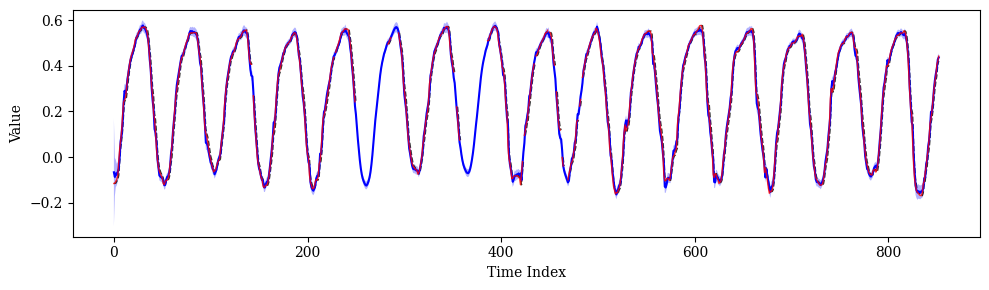

In [45]:
plot_results_with_baseline(
    prior, posterior, y_true, s_aleatoric, data, plot_baseline=True
)